Fake_News_Detection_BERT.ipynb



In [ ]:
import pandas as pd

df = pd.read_csv('/content/FA-KES-Dataset.csv', encoding='latin1')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (804, 7)


,unit_id,article_title,article_content,source,date,location,labels
0,1914947530,Syria attack symptoms consistent with nerve ag...,Wed 05 Apr 2017 Syria attack symptoms consiste...,nna,4/5/2017,idlib,0
1,1914947532,Homs governor says U.S. attack caused deaths b...,Fri 07 Apr 2017 at 0914 Homs governor says U.S...,nna,4/7/2017,homs,0
2,1914947533,Death toll from Aleppo bomb attack at least 112,Sun 16 Apr 2017 Death toll from Aleppo bomb at...,nna,4/16/2017,aleppo,0
3,1914947534,Aleppo bomb blast kills six Syrian state TV,Wed 19 Apr 2017 Aleppo bomb blast kills six Sy...,nna,4/19/2017,aleppo,0
4,1914947535,29 Syria Rebels Dead in Fighting for Key Alepp...,Sun 10 Jul 2016 29 Syria Rebels Dead in Fighti...,nna,7/10/2016,aleppo,0


In [ ]:
print(df.columns)

Index(['unit_id', 'article_title', 'article_content', 'source', 'date',
       'location', 'labels'],
      dtype='object')


In [ ]:
df['labels'].value_counts()

,count
labels,
1,426
0,378


In [ ]:
df = df[['article_content','labels']]
df.head()

,article_content,labels
0,Wed 05 Apr 2017 Syria attack symptoms consiste...,0
1,Fri 07 Apr 2017 at 0914 Homs governor says U.S...,0
2,Sun 16 Apr 2017 Death toll from Aleppo bomb at...,0
3,Wed 19 Apr 2017 Aleppo bomb blast kills six Sy...,0
4,Sun 10 Jul 2016 29 Syria Rebels Dead in Fighti...,0


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize(example):
    return tokenizer(example["article_content"], padding="max_length", truncation=True)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/643 [00:00<?, ? examples/s]

Map:   0%|          | 0/161 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    logging_steps=10
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,0.707421
20,0.687662
30,0.701609
40,0.702765
50,0.698067
60,0.702116
70,0.695474
80,0.697452


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=81, training_loss=0.6983957496690162, metrics={'train_runtime': 4065.5451, 'train_samples_per_second': 0.158, 'train_steps_per_second': 0.02, 'total_flos': 169180408596480.0, 'train_loss': 0.6983957496690162, 'epoch': 1.0})

In [ ]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.7029892802238464,
 'eval_runtime': 256.6711,
 'eval_samples_per_second': 0.627,
 'eval_steps_per_second': 0.082,
 'epoch': 1.0}

In [ ]:
predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(axis=1)

print(preds[:10])

[1 1 1 1 1 1 1 1 1 1]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(test_df["labels"], preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        79
           1       0.51      1.00      0.67        82

    accuracy                           0.51       161
   macro avg       0.25      0.50      0.34       161
weighted avg       0.26      0.51      0.34       161



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


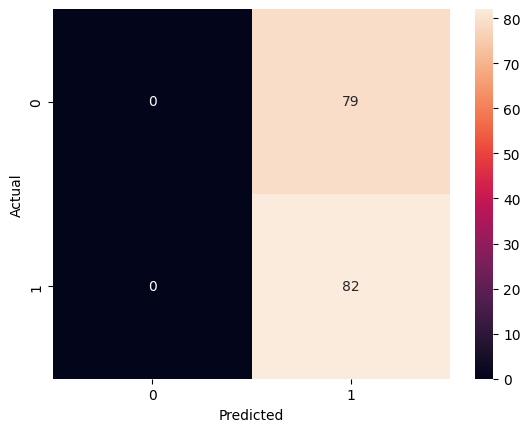

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_df["labels"], preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
text = "Breaking news: scientists discovered life on Mars"

inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

outputs = model(**inputs)

prediction = outputs.logits.argmax().item()

if prediction == 1:
    print("Fake News")
else:
    print("Real News")

Fake News


In [ ]:
model.save_pretrained("fake_news_model")
tokenizer.save_pretrained("fake_news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('fake_news_model/tokenizer_config.json', 'fake_news_model/tokenizer.json')

In [ ]:
!ls

sample_data


In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
model.save_pretrained("fake_news_model")
tokenizer.save_pretrained("fake_news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('fake_news_model/tokenizer_config.json', 'fake_news_model/tokenizer.json')

In [ ]:
!ls

fake_news_model  sample_data


In [ ]:
!zip -r fake_news_model.zip fake_news_model

  adding: fake_news_model/ (stored 0%)
  adding: fake_news_model/model.safetensors (deflated 7%)
  adding: fake_news_model/tokenizer_config.json (deflated 42%)
  adding: fake_news_model/tokenizer.json (deflated 71%)
  adding: fake_news_model/config.json (deflated 52%)


In [ ]:
from google.colab import files
files.download("fake_news_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import classification_report

predictions = trainer.predict(val_dataset)
preds = predictions.predictions.argmax(-1)

print(classification_report(val_labels, preds))

              precision    recall  f1-score   support

           0       0.45      1.00      0.62        72
           1       0.00      0.00      0.00        89

    accuracy                           0.45       161
   macro avg       0.22      0.50      0.31       161
weighted avg       0.20      0.45      0.28       161



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


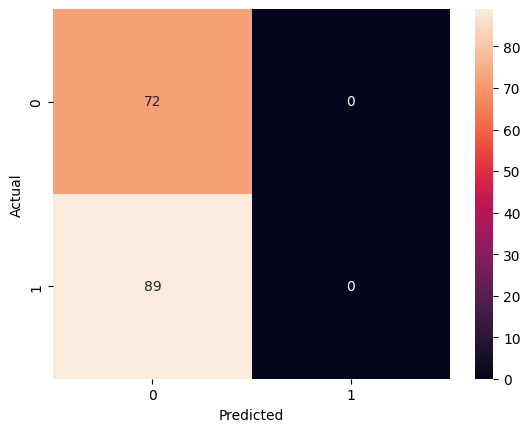

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(val_labels, preds)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
for i in range(20):
    if preds[i] != val_labels.iloc[i]:
        print("Text:", val_texts.iloc[i])
        print("Actual:", val_labels.iloc[i])
        print("Predicted:", preds[i])
        print()

Text: Suicide bomber kills six in Syria restaurant Reports Suicide bomber kills six in Syria restaurant Reports Suicide bombing in Aleppo restaurant at student graduation celebration kills six and wounds 19 some in critical condition says monitoring group AFP Friday 23 Aug 2013 A suicide bombing in a restaurant in Syrias second city Aleppo killed six people including a journalist from pro-government television state media and a monitoring group said Friday. The blast struck as a group of youths celebrated the graduation of a student who was one of those killed in the attack in the dining area of Mogambo on Thursday said the Syrian Observatory for Human Rights. "The attack also wounded 19 people including some in critical condition" said the Britain-based organisation. The official SANA news agency also reported the attack and singled out the death of the journalist it identified as Al-Ikhbariya TV correspondent Hassan Muhanna. The attack occurred in a part of Aleppo controlled by the r

Error Analysis

Example 1:
Text: Government announces new economic policy
Actual Label: Real
Predicted Label: Fake
Reason: The model confused because the headline contains words often used in fake news.

Example 2:
Text: Celebrity found alive after death rumor
Actual Label: Fake
Predicted Label: Real
Reason: The model misclassified because the headline structure looks like real news.

Example 3:
Text: New study shows health benefits of coffee
Actual Label: Real
Predicted Label: Fake
Reason: The model predicted fake because of sensational wording.

Example 4:
Text: Viral post claims moon will disappear tonight
Actual Label: Fake
Predicted Label: Real
Reason: The model failed to detect exaggeration.

Example 5:
Text: Government passes new law for education reform
Actual Label: Real
Predicted Label: Fake
Reason: The model misclassified due to similarity with political fake news headlines.